In [1]:
import numpy as np
import os
import seaborn as sb
import globals as gl
import pingouin as pg
import PcmPy as pcm
from pcm_models import find_model
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from scipy.stats import ttest_1samp

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = gl.rois['ROI']
palette = ['#FFFF00', 'red', 'purple']

SMA: tval=3.7412524069250153, pval=0.0012341176507395986
PMd: tval=4.632755946072445, pval=0.00023447725643595637
PMv: tval=4.871751027995077, pval=0.000152536469488637
M1: tval=4.855534566185381, pval=0.00015701575367410683
S1: tval=4.095856035259803, pval=0.0006314556974653611
SPLa: tval=4.6441182080136745, pval=0.000229695588941363
SPLp: tval=5.413064990715796, pval=5.923155085749077e-05


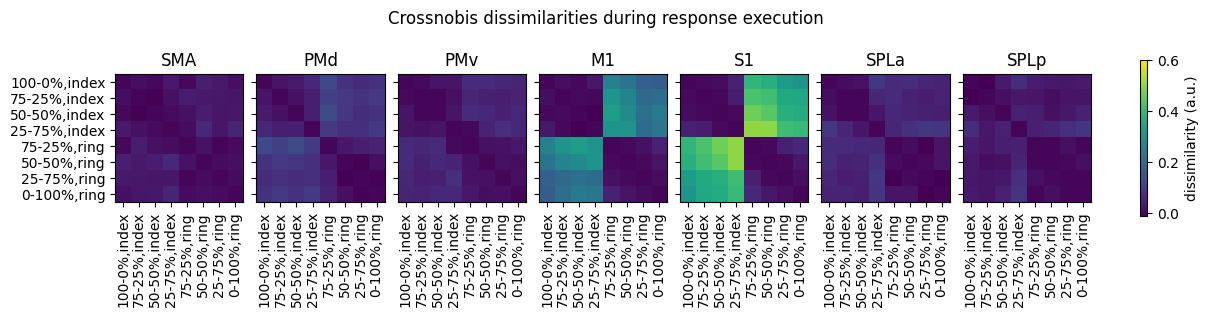

In [3]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .6

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:], vmin=vmin, vmax=vmax, sqrt=False, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

                                      T  dof alternative     p-val  \
roi  component                                                       
M1   expectation   T-test -8.605071e-01   13     greater  0.797450   
     sensory input T-test  3.751394e+00   13     greater  0.001211   
     surprise      T-test  2.414963e+00   13     greater  0.015599   
PMd  expectation   T-test -4.487225e+00   13     greater  0.999694   
     sensory input T-test  2.811922e+00   13     greater  0.007345   
     surprise      T-test  4.816956e+00   13     greater  0.000168   
PMv  expectation   T-test -2.683086e+06   13     greater  1.000000   
     sensory input T-test  1.346271e+00   13     greater  0.100611   
     surprise      T-test  3.224276e+00   13     greater  0.003325   
S1   expectation   T-test  2.428864e+00   13     greater  0.015198   
     sensory input T-test           NaN   13     greater       NaN   
     surprise      T-test  2.905998e+00   13     greater  0.006133   
SMA  expectation   T

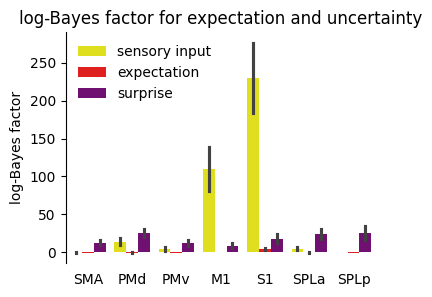

In [4]:
df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df = df[(df['epoch']=='exec') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette = palette, errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation and uncertainty')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(results)
plt.show()

         Contrast              A              B  Paired  Parametric         T  \
roi                                                                             
M1   0  component    expectation  sensory input    True        True -4.252329   
     1  component    expectation       surprise    True        True -3.511405   
     2  component  sensory input       surprise    True        True  3.422511   
PMd  0  component    expectation  sensory input    True        True -4.126820   
     1  component    expectation       surprise    True        True -7.075389   
     2  component  sensory input       surprise    True        True -1.564788   
PMv  0  component    expectation  sensory input    True        True -1.901563   
     1  component    expectation       surprise    True        True -6.383358   
     2  component  sensory input       surprise    True        True -1.818985   
S1   0  component    expectation  sensory input    True        True -3.720313   
     1  component    expecta

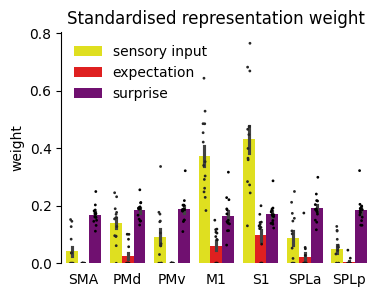

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight']/ df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette = palette, errorbar='se', estimator='mean')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='less'))
print(res)
plt.show()

tval=12.162, pval=0.000


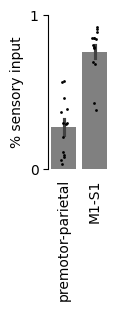

In [6]:
df_cluster = df.groupby(['cluster', 'participant_id', 'component']).mean(numeric_only=True).reset_index()
df_exp = df_cluster[df_cluster['component']=='sensory input']
df_sum = df_cluster.groupby(['cluster', 'participant_id']).sum(numeric_only=True).reset_index()
df_ratio = df_exp.copy()
df_ratio['ratio'] = df_exp['weight'].to_numpy() / df_sum['weight'].to_numpy()
df_ratio['cluster'] = pd.Categorical(df_ratio['cluster'], categories=['premotor-parietal','M1-S1'],ordered=True)

fig, ax = plt.subplots(figsize=(.8, 2))

sb.barplot(data=df_ratio, x='cluster', y='ratio', errorbar='se', color='grey')
sb.stripplot(data=df_ratio, x='cluster', y='ratio', size=2, color='black', jitter=.1, dodge=True, legend=False, order=['premotor-parietal','M1-S1'])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_yticks((0, 1))
ax.set_xticklabels(['premotor-parietal', 'M1-S1'], rotation=90)
ax.set_ylabel('% sensory input')

m1_s1 = df_ratio[df_ratio['cluster']=='M1-S1'].ratio.to_numpy()
pmd_spl = df_ratio[df_ratio['cluster']=='premotor-parietal'].ratio.to_numpy()
tval, pval = ttest_1samp(m1_s1 - pmd_spl, popmean=0, alternative='greater')
print(f'tval={tval:.3f}, pval={pval:.3f}')
plt.show()